# Nonlinear Heat Conduction Problem with hyper-reduction, reduction and full order simulation

![Problem Schematic](problem_schematics.png)

## Environment Setup

### Directories

In [1]:
import sys
from pathlib import Path
import importlib
# -----------------------------------------------------------------------------
# Project-root auto-detection script
# Ensures the top-level directory (containing 'src/' and 'tests/')
# is on Python's import path, allowing modules to be imported consistently
# regardless of the current working directory (e.g., in notebooks).
# -----------------------------------------------------------------------------

# 1) Start from the current working directory (or notebook location)
notebook_path = Path().resolve()
linear_dir = notebook_path.parent     # .../linear
# 2) Traverse upward through parent directories to find the project root
for parent in notebook_path.parents:
    # Check for indicators of the project's root structure
    if (parent / "src").exists() and (parent / "tests").exists():
        project_root = parent
        break
else:
    # If loop completes without break, no valid root was found
    raise RuntimeError(
        "Could not find project root containing 'src' and 'tests'"
    )

# 3) Prepend the detected root to sys.path to prioritize local modules
sys.path.insert(0, str(project_root))

if str(linear_dir) not in sys.path:
    sys.path.insert(0, str(linear_dir))
    
# 4) Confirm successful addition (optional print for debugging)
print("Project root added to sys.path:", project_root)

Project root added to sys.path: D:\OneDrive - Texas A&M University\SKROM\SCIKIT-ROM


### Standard Imports

In [2]:
#Standard Imports and class import
from src.skrom.utils.imports import *
from src.skrom.rom.rom_utils import *
from src.skrom.utils.reduced_basis.svd import svd_mode_selector
from src.skrom.rom.rom_error_est import *
from src.skrom.utils.visualization.color_palette import set_color_palette
import src.skrom.problem_classes.master_class_static as master
importlib.import_module("problem_2_h.problem_def")   # this runs @register_problem    

# SKROM ROM (Reduced Order Modeling) core classes
from src.skrom.rom.linear_form_rom import LinearFormROM
from src.skrom.rom.ecsw.hyperreduce import hyperreduce
# Problem-specific linear forms
from tests.computational_mechanics.static.non_linear.problem_2_h.linear_forms import R

### Plot Properties


In [3]:
# # Define a custom color palette with 19 distinct colors
set_color_palette();

## Full Order Simulation


In [4]:
# Control flag for expensive simulation generation

generate = False

# Conditional execution block for simulation data generation
if generate:
    # Create an instance of the non-linear heat conduction simulation
    sim = master.fom_simulation(num_snapshots = 32)
    sim.run_simulation()


### Load Simulation Data

In [5]:
#Load the ROM_data
current_dir = Path().resolve()
rom_dir = current_dir / "ROM_data"
fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=rom_dir)

[load_rom_data] loaded from D:\OneDrive - Texas A&M University\SKROM\SCIKIT-ROM\tests\computational_mechanics\static\non_linear\problem_2_h\ROM_data


## Data Generation

### Generate Training Solution Dataset



In [6]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = np.asarray(sim_data['param_list'])

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
NLS = np.asarray(fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = sim_data['train_mask'], sim_data['test_mask']

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
NLS_train = NLS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
NLS_test = NLS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(NLS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available

64


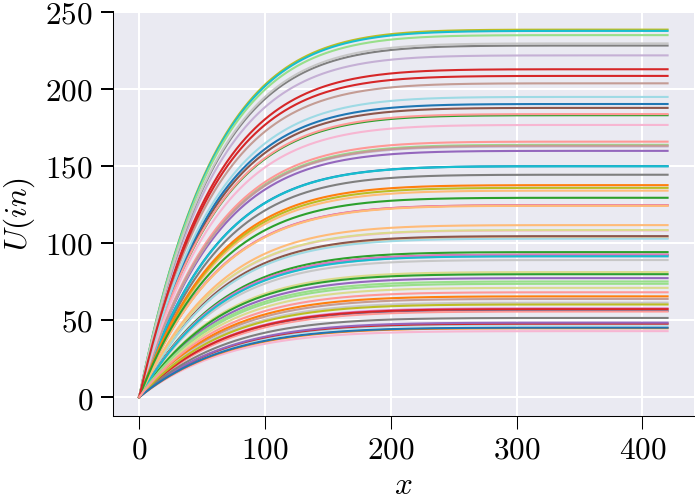

In [7]:
# Plot the computed temperature distribution
# Create a figure with specified dimensions (5x3.5 inches) for compact visualization
plt.figure(figsize=(5, 3.5))

# Extract spatial coordinates from the mesh data
# The mesh is stored as an object in sim_data, accessed via .item() to get the actual mesh
# mesh.p[0] contains the x-coordinates of the mesh nodes (1D spatial domain)
mesh_domain = sim_data['mesh'].item().p[0]

# Plot temperature profiles for all parameter combinations
# Loop through all non-linear solutions (each row is a complete temperature field)
for j in range(len(NLS)):
    # Plot each temperature distribution as a line
    # x-axis: spatial coordinates from the mesh
    # y-axis: temperature values at each spatial location
    # '-' specifies solid line style, markersize affects any markers
    plt.plot(mesh_domain, NLS[j], '-', markersize=2)

# Set axis labels with proper mathematical notation
plt.xlabel("$x$")        # Spatial coordinate (LaTeX formatting)
plt.ylabel("$U (in)$")    # Temperature in Kelvin (LaTeX formatting)

# Display the plot
plt.show()

### Mean Subtraction

In [8]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
NLS_train_mean = np.mean(NLS_train, axis=0)

# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
NLS_train_ms = NLS_train - NLS_train_mean

#We will use SVD on the mean subtracted matrix data

### Distribution of the training parameters

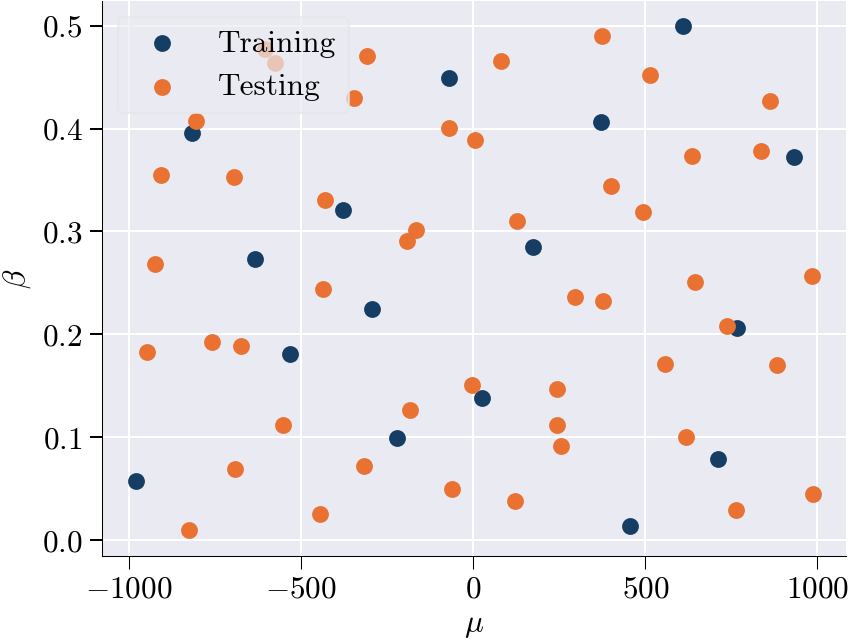

In [9]:
# Visualize the parameter space distribution for training and testing data
# Plot training parameter combinations (first 16 samples)
# Extract first and second parameter columns for 2D visualization
plt.scatter(param_list[:16][:, 0],    # First parameter (μ) for training samples which are the k_params 
           param_list[:16][:, 1],     # Second parameter (β) for training samples which are the q_params
           s=50,                      # Marker size
           c='#163e64',              # Dark blue color for training points
           label="Training")         # Legend label

# Plot testing parameter combinations (samples 17 and beyond)
plt.scatter(param_list[16:][:, 0],    # First parameter (μ) for testing samples
           param_list[16:][:, 1],     # Second parameter (β) for testing samples
           s=50,                      # Marker size (same as training)
           c='#e97132',              # Orange color for testing points
           label="Testing")          # Legend label

# Set axis labels using LaTeX formatting for mathematical notation
plt.xlabel("$\\mu$")        # First parameter (often material property, conductivity, etc.) this is the k_params
plt.ylabel("$\\beta$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

# Add legend to distinguish between training and testing sets
plt.legend()

#See params and properties to see how these are used

### Performing SVD on training snapshots

Number of modes selected: 4


Text(0.5, 0, 'POD modes ($k$)')

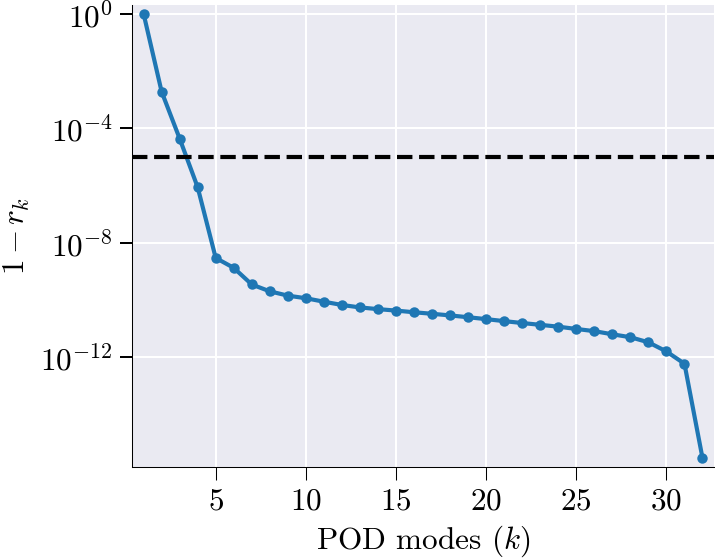

In [10]:
# Configure plot styling for POD analysis visualization
plt.rcParams['lines.markersize'] = 6      # Set marker size for data points
plt.rcParams['lines.linewidth'] = 2.0     # Set line thickness for better visibility

# Perform Singular Value Decomposition (SVD) for POD mode selection
# SVD decomposes the mean-centered training data to find optimal basis functions
n_sel, U = svd_mode_selector(NLS_train_ms,    # Input: mean-centered training snapshots
                            tolerance=1e-5,    # Convergence criterion for mode selection
                            modes=True)        # Return both number of modes and basis vectors


# Extract the selected POD basis vectors (spatial modes)
# V_sel contains the first n_sel most energetic POD modes
# Shape: [N_dof, n_sel] - each column is a spatial basis function
V_sel = U[:, :n_sel]  # This will be passed to the ROM simulation function

# Set axis labels for the POD energy plot (generated by svd_mode_selector)
plt.ylabel('$1-r_{k}$')           # Energy not captured by first k modes
plt.xlabel('POD modes ($k$)')     # Number of POD modes retained

## ROM Simulation


In [11]:
# Initialize the reduced-order model (ROM) simulation
#   V_sel : precomputed basis matrix (e.g., selected POD modes)
#   n_sel : number of basis vectors (modes) to retain in the ROM
rom = master.rom_simulation(V_sel=V_sel, n_sel = n_sel)

[load_rom_data] loaded from d:\OneDrive - Texas A&M University\SKROM\SCIKIT-ROM\tests\computational_mechanics\static\non_linear\problem_2_h\ROM_data


In [12]:
# Run the reduced-order model (ROM) simulation.
# rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
generate = True
if generate:
    rom.run_rom_simulation();
#Returns the Newton iteration errors just like full order simulation

Snap 1/64 params=[-5.76016854e+02  4.63766078e-01]
[Newton] Iter  0, step norm = 9.567e+03
[Newton] Iter  1, step norm = 2.581e+03
[Newton] Iter  2, step norm = 1.065e+02
[Newton] Iter  3, step norm = 1.767e-01
[Newton] Iter  4, step norm = 2.193e-02
[Newton] Iter  5, step norm = 6.680e-04
Snap 2/64 params=[6.16779340e+02 1.00077258e-01]
[Newton] Iter  0, step norm = 2.956e+04
[Newton] Iter  1, step norm = 2.734e+04
[Newton] Iter  2, step norm = 2.749e+04
[Newton] Iter  3, step norm = 3.242e+04
[Newton] Iter  4, step norm = 4.249e+04
[Newton] Iter  5, step norm = 9.110e+04
[Newton] Iter  6, step norm = 1.599e+05
[Newton] Iter  7, step norm = 4.665e+05
[Newton] Iter  8, step norm = 1.024e+06
[Newton] Iter  9, step norm = 3.112e+06
[Newton] Iter 10, step norm = 7.711e+06
[Newton] Iter 11, step norm = 2.323e+07
[Newton] Iter 12, step norm = 6.138e+07
[Newton] Iter 13, step norm = 1.821e+08
[Newton] Iter 14, step norm = 4.983e+08
[Newton] Iter 15, step norm = 1.456e+09
[Newton] Iter 16, st

In [13]:
#Assign values for the statistics
NLS_rom = np.asarray(rom.rom_solutions)
ROM_speed_up = rom.speed_up
ROM_speed_up=ROM_speed_up
ROM_relative_error = rom.rom_error

### ROM solution vs. Full order solution performance statistics 

ROM Accuracy Report

Global Errors:
L2 Error:                 3.1951e-02
Relative L2 Error:        3.6140e-07
L∞ Error:                 1.0528e-04
Relative L∞ Error:        4.4857e-07
RMSE:                     4.4126e-05
MAE:                      3.7997e-05

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             3.2633e-06
95th Percentile Error:    8.3031e-05

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 5.3509e-07
Max Rel L2 Error over time/parameter: 1.5368e-06
Min Rel L2 Error over time/parameter: 1.9730e-07
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

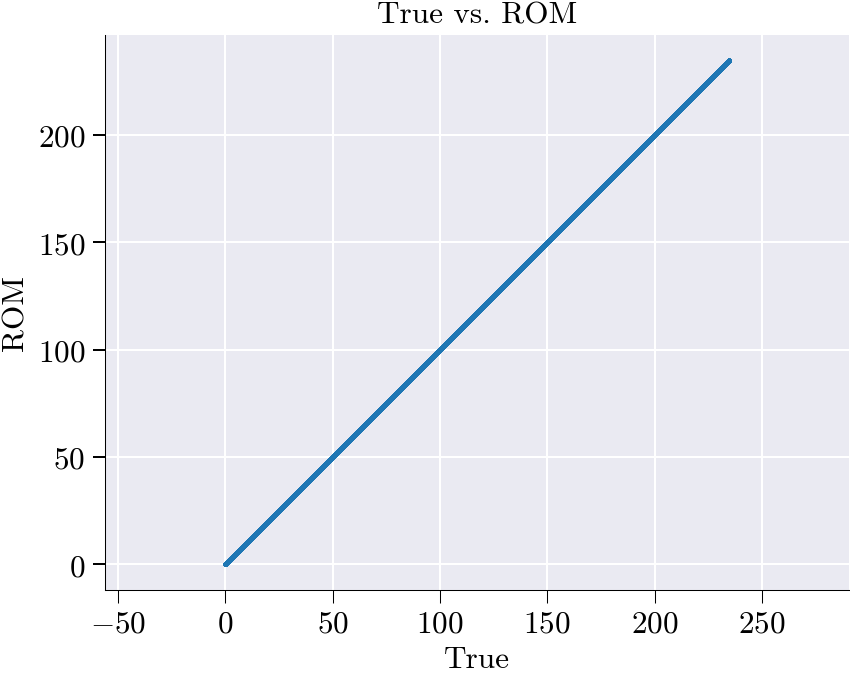

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


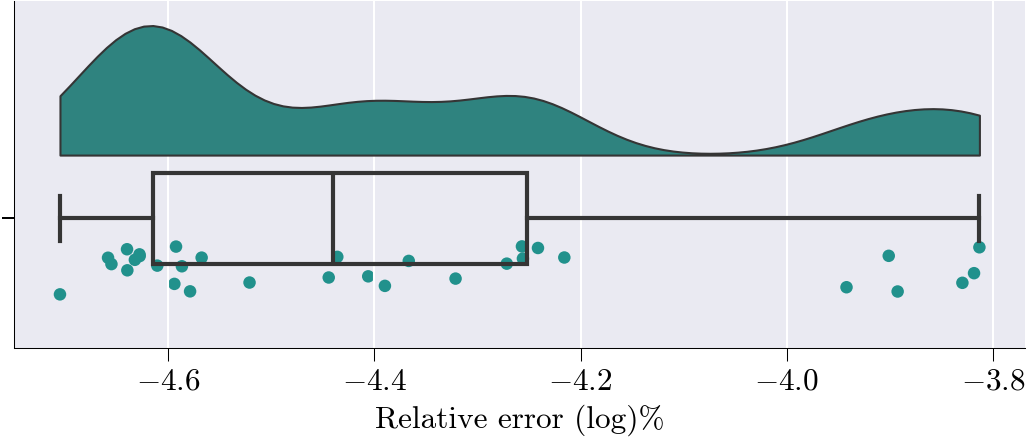

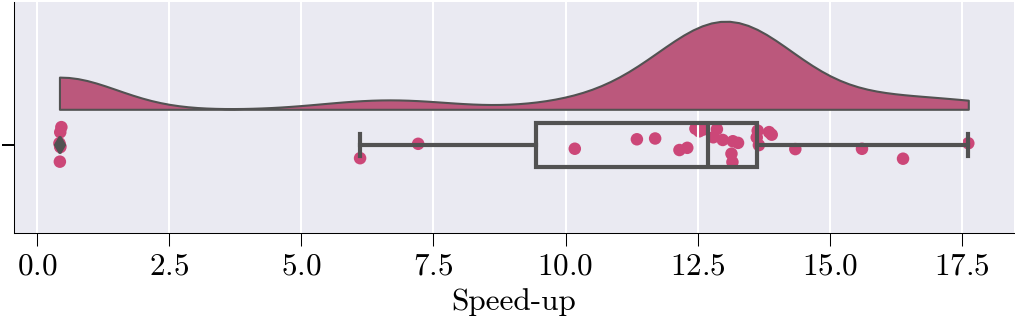

In [14]:
# --- Standard ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_rom)

# Produce a text-based report summarizing these error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the standard ROM
plot_rom_error_diagnostics_flat(
    NLS_test,               # full-order (true) solution snapshots
    NLS_rom,                # ROM-generated solution snapshots
    ROM_relative_error,     # precomputed relative error of the ROM
    ROM_speed_up,           # precomputed speed-up factor of the ROM
    sim_axis=['True', 'ROM'], 
    metrics=matrix          # the matrix of error metrics just computed
)


## Hyper ROM Simulation


### Mesh Sampling


In [15]:
from tests.computational_mechanics.static.non_linear.problem_2_h.problem_def import ProblemNonLinear

In [16]:
prob = ProblemNonLinear()
sim_data['dirichlet_dofs'] = prob.domain()['dirichlet_boundary_dofs']
free_dofs = prob.domain()['free_dofs']

In [17]:
# Get the finite element basis object for ROM construction
# This contains the spatial discretization information and basis functions
basis = sim_data['basis'].item()

# Create the ROM residual linear form object
# This represents the linear form R(u,v) in the weak formulation of the PDE
Residual = LinearFormROM(R,                    # Linear form function from problem definition
                         basis,                 # Finite element basis functions
                         V_sel,                 # Selected POD modes (reduced basis)
                         free_dofs=free_dofs)   # Free DOFs (excluding Dirichlet boundaries)

# Extract parameter values corresponding to training snapshots
# Uses the boolean mask to get only the parameter combinations used for training
training_params = param_list[train_mask]

In [18]:
def collect_residuals(
    NLS_train_ms,
    NLS_train_mean,
    V_sel,
    reconstruct_solution,
    Residual,
):
    """
    Collect reduced evaluations of the ROM residual functional for hyperreduction.
    
    This function processes training snapshots to collect residual evaluations that will
    be used for hyperreduction (reducing computational cost of nonlinear ROM terms).
    
    Parameters
    ----------
    fos_solutions : ndarray
        Full order solutions (not directly used but maintained for interface consistency)
    NLS_train_ms : ndarray, shape (n_snapshots, n_dofs)
        Mean-subtracted training snapshots (temperature fluctuations from mean)
    NLS_train_mean : ndarray, shape (n_dofs,)
        Mean temperature field across all training snapshots
    V_sel : ndarray, shape (n_dofs, n_modes)
        Selected POD basis matrix (reduced basis vectors)
    reconstruct_solution : callable
        Function to reconstruct full-order solution from ROM coefficients
        Signature: u_full = reconstruct_solution(u_reduced, V_sel, u_mean)
    Residual : LinearFormROM object
        ROM residual operator with hyperreduction capability
        Must have method: hyperreduction(prev=solution, k_param=k, q_param=q)
    
    Returns
    -------
    q_mus : ndarray, shape (n_snapshots, n_residual_components)
        Collected residual evaluations for all training snapshots
        Each row contains the hyperreduced residual evaluation for one parameter case
    """
    
    # Initialize storage for residual evaluations
    q_mus = None
    
    # Down-sampling factor for processing snapshots (currently set to 1 = no downsampling)
    step = 1
    
    # Loop through all mean-centered training snapshots
    for i, u_arr_ms in enumerate(NLS_train_ms):
                
        # Project mean-centered snapshot to reduced coordinates
        # This gives the ROM coefficients for this parameter case
        u_red = V_sel.T @ u_arr_ms

        # Reconstruct the full-order solution from ROM coefficients
        # Combines: full_solution = mean_field + ROM_basis * ROM_coefficients
        u_rec = reconstruct_solution(u_red, V_sel, NLS_train_mean)
        
        # Extract parameter values for this snapshot (thermal conductivity, boundary condition)
        kw = prob.assemble_kwargs(u_rec, training_params[i])

        # Apply hyperreduced residual operator to get reduced residual evaluation
        # This evaluates the nonlinear residual at a subset of quadrature points
        # prev: previous solution state, k_param: thermal conductivity, q_param: heat source
        q = Residual.hyperreduction(**kw).T.copy()
        
        # Stack residual evaluations from all snapshots
        if q_mus is None:
            # Initialize with first snapshot's residual
            q_mus = q
        else:
            # Concatenate new snapshot residual "on top" of existing array (axis=0)
            q_mus = np.concatenate((q_mus, q), axis=0)
    
    return q_mus

# Collect residual evaluations for all training snapshots
# This creates the dataset needed for hyperreduction of nonlinear ROM terms
q_mus = collect_residuals(
    NLS_train_ms,         # Mean-centered training snapshots
    NLS_train_mean,       # Mean temperature field
    V_sel,                # Selected POD basis modes
    reconstruct_solution, # Solution reconstruction function
    Residual,             # ROM residual operator
)

# Display the shape of collected residuals for verification
# Shape should be: (n_training_snapshots * SVD components, n_residual_evaluation_points)
print(q_mus.shape)

#Output should be 16(for training snapshots) * 5(SVD components selected) = 80

(128, 16384)


#### Performing the SVD on snapshots

Performing SVD...
magnitude of d_q: 127.99603027727007


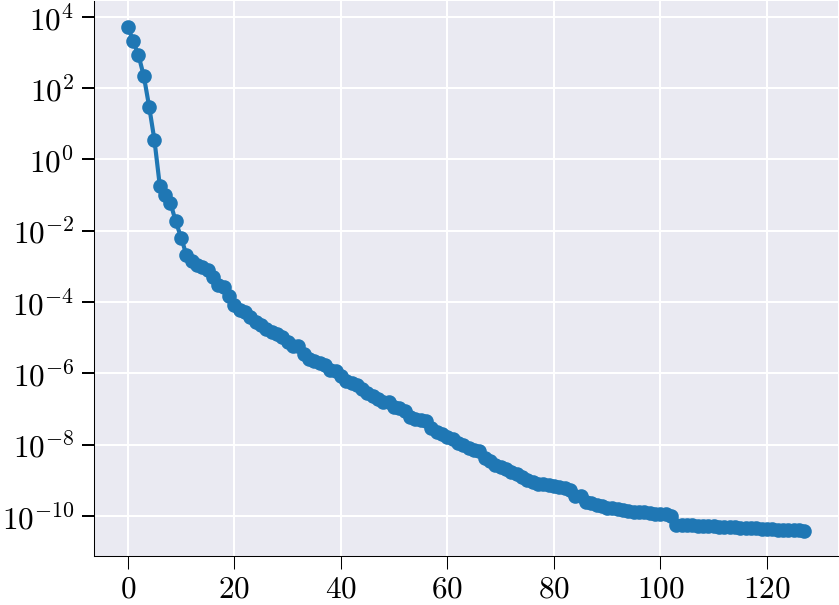

In [26]:
print("Performing SVD...")
# Performs Singular Value Decomposition on q_mus matrix
# Returns U (left singular vectors), s (singular values), Vh (right singular vectors transposed)
Uh, s, Vh = np.linalg.svd(q_mus, full_matrices=False)

# Plots singular values on a logarithmic y-scale to visualize their decay
# This helps identify the effective rank/dimensionality of the matrix
plt.semilogy(s, 'o-')

# Takes the first 20 right singular vectors (rows of Vh)
# This creates a reduced basis capturing the most significant modes
V_q_eff = Vh[:80]

# Computes a weighted combination of the basis vectors
# Each basis vector is weighted equally (multiplied by 1)
# This essentially sums all 20 basis vectors
d_q = V_q_eff @ np.ones(V_q_eff.shape[1])

# Outputs the L2 norm of the resulting vector
# This gives a sense of the magnitude of the combined basis representation
print("magnitude of d_q:", np.linalg.norm(d_q))

#### NNLS matrix

In [27]:
# Solve the non-negative least squares (NNLS) problem using hyperreduce
#   V_q_eff   : effective basis matrix
#   verbosity : level of log output (2 = detailed)
#   const_tol : tolerance for column selection
#   zero_tol  : tolerance to treat values as zero
#   plot      : disable plotting
x_nnls_m, err = hyperreduce(
    V_q_eff,
    verbosity=2,
    const_tol=1e-8,
    zero_tol=1e-8,
    plot=False
)

# Compute and print the relative NNLS reconstruction error:
#   ‖q_mus·(x_nnls_m – 1)‖ / ‖q_mus·1‖
rel_error = np.linalg.norm(q_mus @ (x_nnls_m - np.ones_like(x_nnls_m)))
rel_error /= np.linalg.norm(q_mus @ np.ones_like(x_nnls_m))
print("NNLS error:", rel_error)

NNLSSolver init (Sequential Version)

Starting NNLS solve...
0 0 80 16384 0 8.379249033161389e+01 1.279960302772701e+02
1 1 80 16384 1 8.380319950958028e+01 1.279870704226510e+02
2 2 80 16384 2 8.388038766147895e+01 1.279734919661185e+02
3 3 80 16384 3 8.397204449391620e+01 1.279554177391720e+02
4 4 80 16384 4 8.398346923251081e+01 1.279303846804977e+02
5 5 80 16384 5 8.415093075865231e+01 1.279186803102339e+02
6 6 80 16384 6 8.414584288743616e+01 1.279087279288852e+02
7 7 80 16384 7 8.446642901658564e+01 1.278872548912032e+02
8 8 80 16384 8 8.446162702057288e+01 1.278652783672675e+02
9 9 80 16384 9 8.448307823459611e+01 1.278557078548734e+02
10 10 80 16384 10 8.428145502289972e+01 1.278473512619684e+02
11 11 80 16384 11 8.440132080022910e+01 1.278388768784099e+02
12 12 80 16384 12 8.437399966282182e+01 1.278303483099508e+02
13 13 80 16384 13 8.431047642464530e+01 1.278221523094301e+02
14 14 80 16384 14 8.427675289437721e+01 1.278146951854033e+02
15 15 80 16384 15 8.424800792653288e+01

#### Plot Reduced Meshes with weights

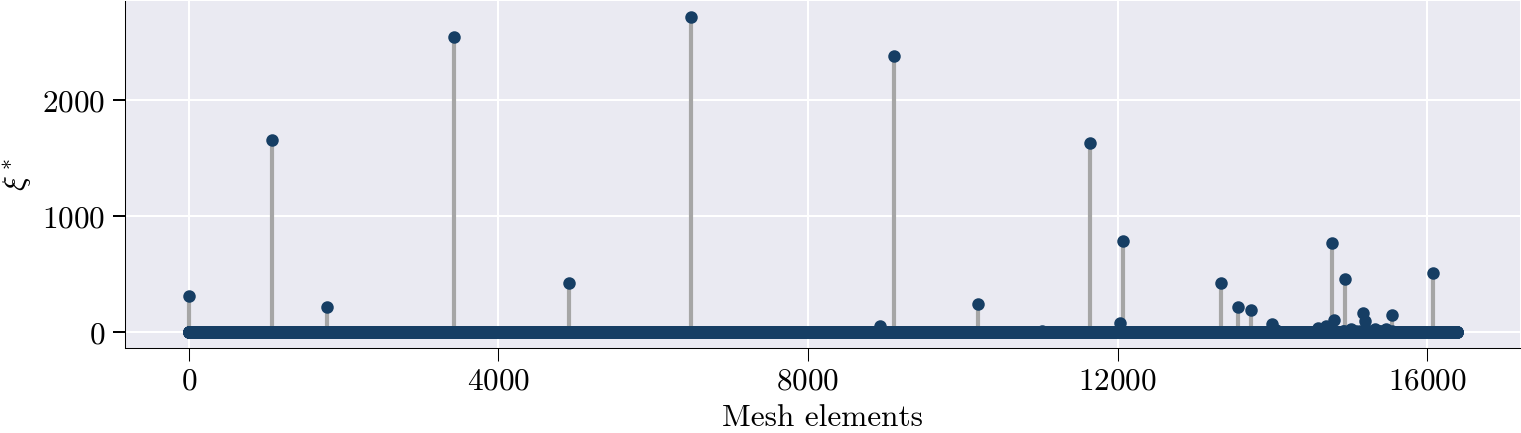

In [28]:
# Set up a figure and axes with a wide aspect ratio
fig_, ax_ = plt.subplots(figsize=(12, 3))

# Create a stem plot:
#   x-values: indices of the NNLS coefficients (0 through len(x_nnls_m)-1)
#   y-values: the NNLS solution vector `x_nnls_m`
#   linefmt : color for the vertical stems
#   markerfmt: marker style and color for the points
#   basefmt : remove the baseline (empty string suppresses drawing)
markerline, stemlines, baseline = ax_.stem(
    np.arange(len(x_nnls_m)),  # x positions
    x_nnls_m,                  # y values
    linefmt='#163e64',         # dark-blue stems
    markerfmt='o',             # circle markers
    basefmt=' '                # no baseline
)

# Further customize the marker appearance
markerline.set_color('#163e64')    # match marker color to stems
markerline.set_markersize(5)       # size of each marker

# Customize the color of the stem lines
stemlines.set_color('#a6a6a6')     # light-gray stems for contrast

# Label the axes
ax_.set_xlabel('Mesh elements')    # horizontal axis label
ax_.set_ylabel('$\\xi^*$')         # vertical axis label, rendered in LaTeX

# Tweak the x-axis tick density:
#   Use at most 6 major ticks, letting Matplotlib choose nice positions
ax_.xaxis.set_major_locator(MaxNLocator(nbins=6))

# Show the plot on screen
# If you want to save instead, uncomment the following line:
# plt.savefig('reduced_mesh_ECSW_new.pdf', dpi=600)
plt.show()

### Run HyperROM simulation


In [ ]:
# Run the hyper-reduced ROM simulation using the NNLS weights
#   x_nnls_m : array of non-negative least squares coefficients,
#              used here to weight the reduced basis contributions
# rom will contain the hyper_rom solution as an attribute

rom.run_hyper_rom_simulation(x_nnls_m)

Snap 1/64 params=[-5.76016854e+02  4.63766078e-01]
[Newton] Iter  0, step norm = 9.582e+03
[Newton] Iter  1, step norm = 2.592e+03
[Newton] Iter  2, step norm = 1.076e+02
[Newton] Iter  3, step norm = 1.671e-01
[Newton] Iter  4, step norm = 4.099e-07
Snap 2/64 params=[6.16779340e+02 1.00077258e-01]
[Newton] Iter  0, step norm = 3.180e+04
[Newton] Iter  1, step norm = 3.500e+04
[Newton] Iter  2, step norm = 3.924e+04
[Newton] Iter  3, step norm = 6.430e+04
[ROM Newton] iter 4: reducing α → 5.00e-01
[Newton] Iter  4, step norm = 9.928e+04
[ROM Newton] iter 5: reducing α → 2.50e-01
[Newton] Iter  5, step norm = 6.992e+02
[Newton] Iter  6, step norm = 5.784e+02
[Newton] Iter  7, step norm = 4.634e+02
[Newton] Iter  8, step norm = 3.638e+02
[Newton] Iter  9, step norm = 2.818e+02
[Newton] Iter 10, step norm = 2.162e+02
[Newton] Iter 11, step norm = 1.649e+02
[Newton] Iter 12, step norm = 1.252e+02
[Newton] Iter 13, step norm = 9.476e+01
[Newton] Iter 14, step norm = 7.155e+01
[Newton] Iter 

([0.011661888570186369,
  0.016793697120864967,
  0.013308257177720014,
  0.01597797396227536,
  0.013054409658798668,
  0.014312986190603947,
  0.012019716554328399,
  0.01557295367108172,
  0.01383407646916339,
  0.015245177853655235,
  0.011421475268120833,
  0.017003110305720843,
  0.012287978868772392,
  0.28807225027874206,
  0.012581903964793766,
  0.014952714258384032,
  0.012799598314949805,
  0.01466834304978631,
  0.012407252855202248,
  0.017877607461973765,
  0.011600352971776973,
  0.016627957035013068,
  0.013992330690123428,
  0.01505343988253657,
  0.012213147406107659,
  0.017902926966285006,
  0.013196363645216596,
  0.014149913732531912,
  0.013544357305675435,
  0.015638123103849138,
  0.011778040557499378,
  0.016245688347165367],
 [37.30346671768918,
  6.048650414169,
  41.41315293738797,
  43.81745843809454,
  47.605883122435905,
  44.11604068333703,
  59.03468551564669,
  1.2732629293871214,
  65.28466311786256,
  50.30392343637524,
  63.14946208066752,
  47.09

In [30]:
rom.hyper_rom_error

[0.011661888570186369,
 0.016793697120864967,
 0.013308257177720014,
 0.01597797396227536,
 0.013054409658798668,
 0.014312986190603947,
 0.012019716554328399,
 0.01557295367108172,
 0.01383407646916339,
 0.015245177853655235,
 0.011421475268120833,
 0.017003110305720843,
 0.012287978868772392,
 0.28807225027874206,
 0.012581903964793766,
 0.014952714258384032,
 0.012799598314949805,
 0.01466834304978631,
 0.012407252855202248,
 0.017877607461973765,
 0.011600352971776973,
 0.016627957035013068,
 0.013992330690123428,
 0.01505343988253657,
 0.012213147406107659,
 0.017902926966285006,
 0.013196363645216596,
 0.014149913732531912,
 0.013544357305675435,
 0.015638123103849138,
 0.011778040557499378,
 0.016245688347165367]

In [31]:
# Convert the list of nonlinear hyper-ROM solutions into a NumPy array
NLS_hyper_rom = np.asarray(rom.hyper_rom_solutions)

# Retrieve the raw speed-up factors computed by the ROM
hyper_ROM_speed_up = rom.hyper_speed_up

# Drop the first element (often the full-order baseline) to analyze only relative speed-ups
hyper_ROM_speed_up = hyper_ROM_speed_up[1:]

# Fetch the relative error of the hyper-reduced ROM from the ROM object
hyper_ROM_relative_error = rom.hyper_rom_error

### Hyper ROM vs Full order solution performance statistics


ROM Accuracy Report

Global Errors:
L2 Error:                 1.9474e+01
Relative L2 Error:        2.2026e-04
L∞ Error:                 3.0904e-01
Relative L∞ Error:        1.3167e-03
RMSE:                     2.6894e-02
MAE:                      1.6174e-02

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       0.9997

Error Distribution:
Median Error:             1.3569e-02
95th Percentile Error:    2.6499e-02

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 2.2744e-04
Max Rel L2 Error over time/parameter: 2.8807e-03
Min Rel L2 Error over time/parameter: 1.1421e-04
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

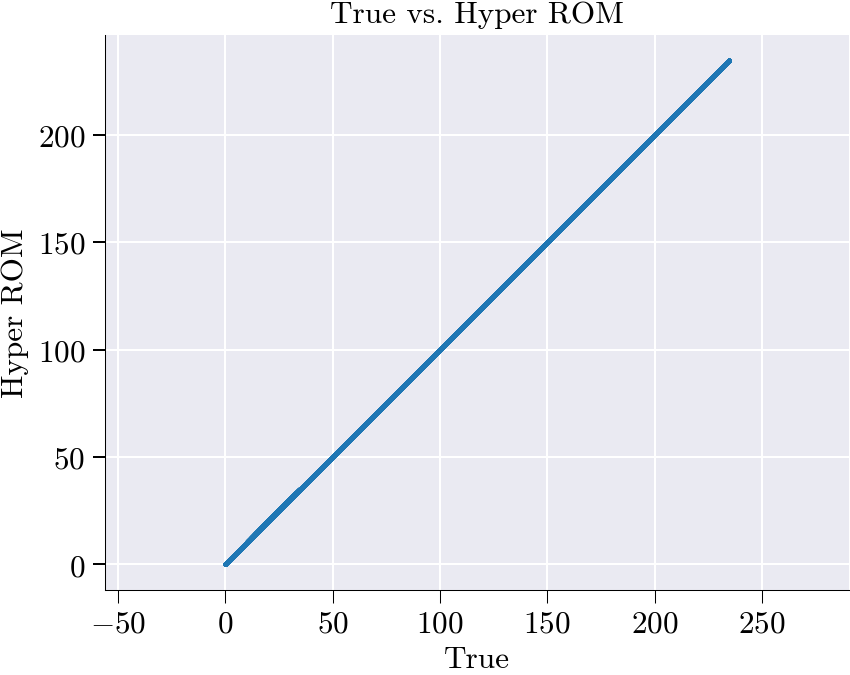

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


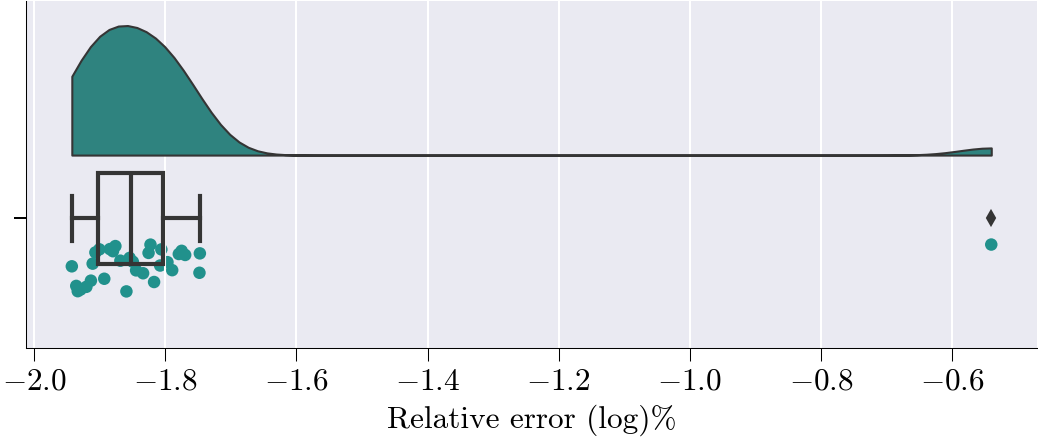

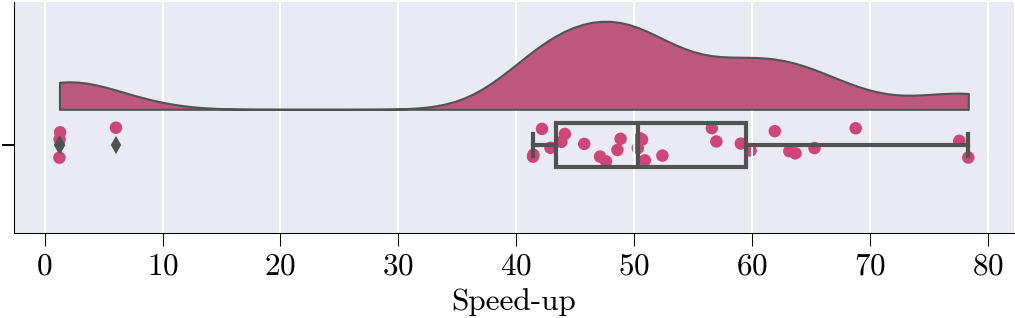

In [32]:
# --- Hyper-reduced ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_hyper_rom)

# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
plot_rom_error_diagnostics_flat(
    NLS_test,                   # full-order (true) solution snapshots
    NLS_hyper_rom,              # hyper-ROM-generated solution snapshots
    hyper_ROM_relative_error,   # precomputed relative error of the hyper-ROM
    hyper_ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
    sim_axis=['True', 'Hyper ROM'], 
    metrics=matrix              # the matrix of error metrics just computed
)

